In [2]:
import os
import math
import time
import operator
import datetime
import h5py
from tqdm import tqdm
import wandb

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import torchvision

import sys
sys.path.append('../../helper_functions/')
from visualization_functions import show_images

def list_to_dict(lst):
    dictionary = {}
    for index, item in enumerate(lst):
        dictionary[index] = item
    return dictionary

def viz_dataloader(dl, n=8, hist=True, label_converter=None):
    batch = next(iter(dl))
    if len(batch[0]) < n: 
        raise ValueError("n is smaller than batch size, increase n")
    inputs = batch[0][:n]
    labels = list(batch[1][:n].numpy())
    if label_converter:
        for i in range(len(labels)):
            labels[i] = label_converter[labels[i]]
    show_images(torch.permute(inputs, [0,2,3,1]).cpu().numpy(), labels=labels, hist_bins=100)            

class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, folder='train', transform=None, classes=[]):
        self.file_path = file_path
        self.folder = folder
        self.transform = transform
        self.hf = None

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.folder]['labels'])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
            
        image = np.array(self.hf[self.folder]['data'][idx])
        labels = np.array(self.hf[self.folder]['labels'][idx])
        
        if self.transform:
            image = self.transform(image)
        return image, labels

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

In [8]:
model = models.resnet50()

model.fc = nn.Sequential(nn.BatchNorm1d(2048),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 2048, out_features=512, bias=False),
                         nn.ReLU(inplace=True),

                         nn.BatchNorm1d(512),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features = 512, out_features=64, bias=False),
                         nn.ReLU(inplace=True),
                         
                         nn.BatchNorm1d(64),
                         nn.Dropout(p=0.5, inplace=False),
                         nn.Linear(in_features=64, out_features=17, bias=True)
                        )
model = torch.load('/mnt/d/models/benchmark-resnet50-from_scratch-05232022-epoch-90.pt')
class Identity(nn.Module):
    def __init__(self):
        super(Identity, self).__init__()
        
    def forward(self, x):
        return x
model.fc = Identity()
model = model.cpu()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
model(torch.randn(1,3,256,256)).shape

torch.Size([1, 2048])

In [21]:
import glob, re

In [32]:
files = glob.glob('/mnt/c/Users/yig319/Downloads/materials_project_root/materials_project_root/*.png')
files

with h5py.File('/mnt/c/datasets/materials_project_root.h5', 'a') as h5:

    for file in files:
        name = re.split('/', file)[-1]
        img = plt.imread(file)[:,:,:3]
        img = torch.tensor(img).permute(2,0,1).unsqueeze(0).float()
        outputs = model(img)
        h5.create_dataset(name, data=outputs.detach().numpy())

<KeysViewHDF5 ['409258704.png', '409258727.png', '409258798.png', '409258857.png', '409258932.png', '409259003.png', '409259097.png', '409259144.png', '409259203.png', '409259262.png', '409259285.png', '409259392.png', '409259502.png', '409259549.png', '409259620.png', '409259683.png', '409259790.png', '409259828.png', '409259896.png', '409259955.png', '409260072.png', '409260131.png', '409260214.png', '409260277.png', '409260338.png', '409260392.png', '409260464.png', '409260535.png', '409260598.png', '409260637.png', '409260696.png', '409260759.png', '409260830.png', '409260893.png', '409260944.png', '409261051.png', '409261114.png', '409261177.png', '409261224.png', '409261339.png', '409261402.png', '409261465.png', '409261536.png', '409261575.png', '409261662.png', '409261733.png', '409261772.png', '409261859.png', '409261906.png', '409261981.png', '409262044.png', '409262091.png', '409262166.png', '409262237.png', '409262340.png', '409262469.png', '409262504.png', '409262581.png',

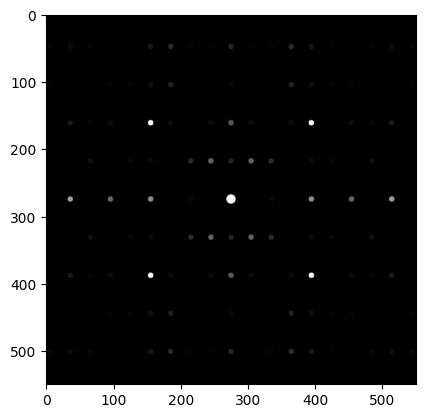

(1, 2048) [[0.35529882 1.0249556  0.27960265 ... 0.6611831  0.7984773  1.465197  ]]


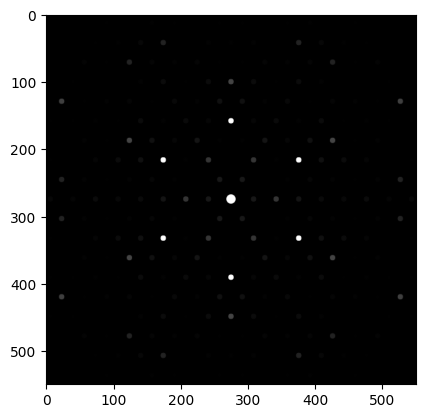

(1, 2048) [[0.7054635  0.6494017  0.5792484  ... 1.1686699  0.94022495 0.8802626 ]]


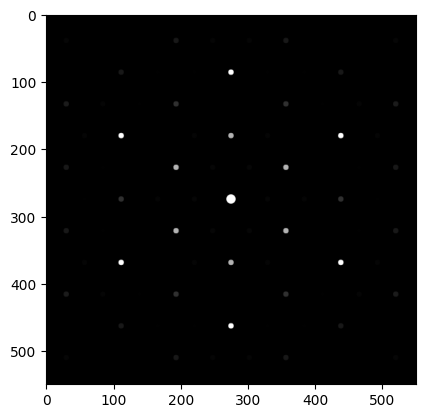

(1, 2048) [[0.32260212 0.7432483  0.86514264 ... 0.9746754  0.6587171  1.2737572 ]]


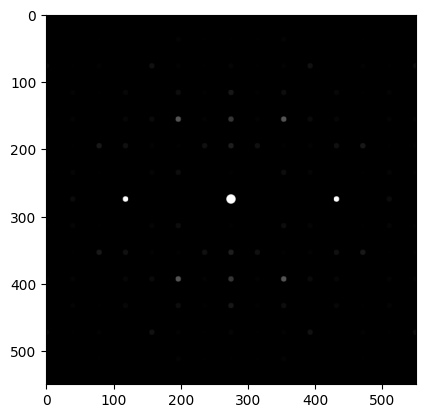

(1, 2048) [[0.7083434  1.0061715  0.59611565 ... 0.52354455 0.60822433 1.39174   ]]


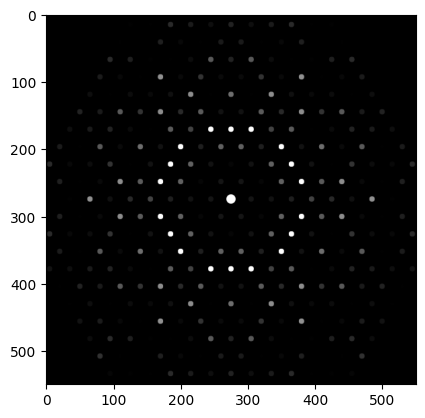

(1, 2048) [[0.08073891 0.7666283  0.55127114 ... 0.86681736 0.5058411  1.4828777 ]]


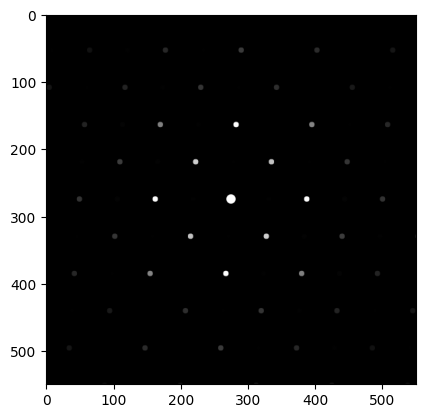

(1, 2048) [[0.36025032 0.6720597  0.68530226 ... 1.1647489  0.7655159  1.5486171 ]]


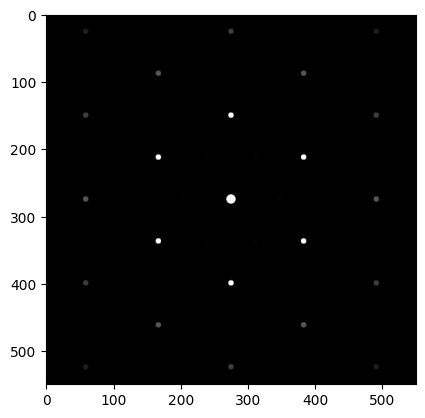

(1, 2048) [[0.57318133 0.9247264  0.6042575  ... 0.75742745 0.82029057 1.0672871 ]]


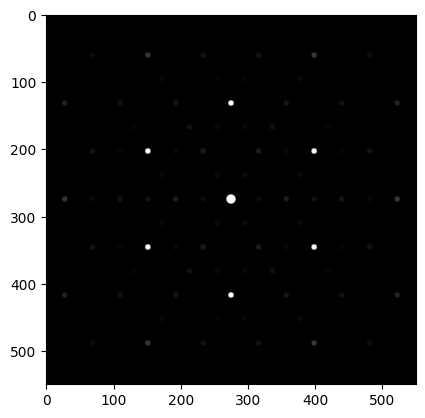

(1, 2048) [[0.23497151 0.7776536  0.72404355 ... 1.0730668  0.51649797 1.3859426 ]]


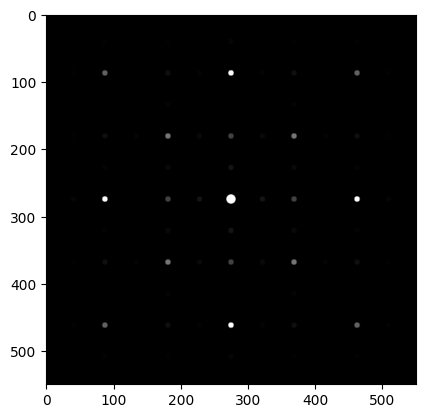

(1, 2048) [[0.11940205 0.8086532  0.5096738  ... 0.8017388  0.7932579  1.1699505 ]]


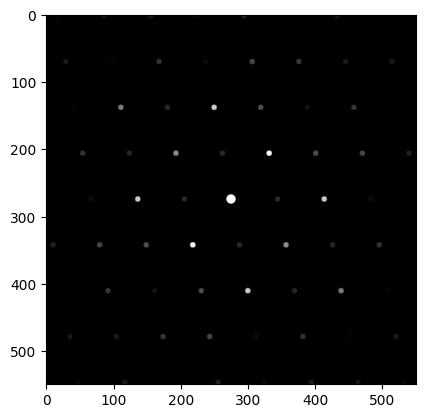

(1, 2048) [[0.47769374 0.91289735 0.96480477 ... 1.1476973  0.4277343  1.1632261 ]]


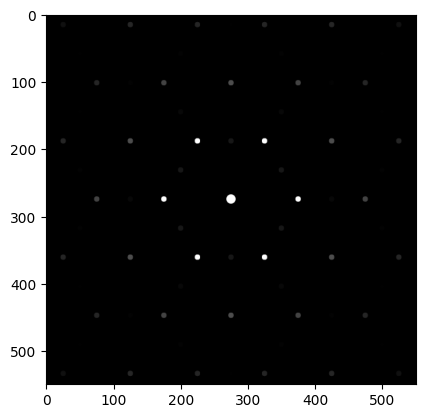

(1, 2048) [[0.28345227 0.7744126  1.3017119  ... 0.57423663 0.47151572 1.5454162 ]]


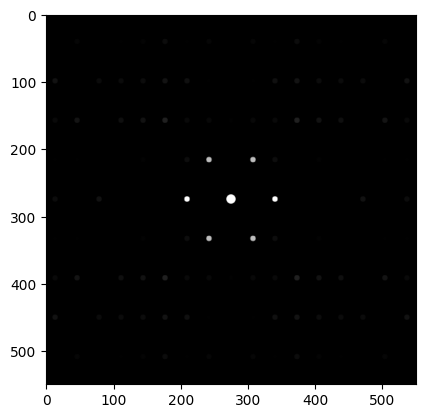

(1, 2048) [[0.3797212  1.3021821  0.6460018  ... 0.33351254 0.9063354  0.48824382]]


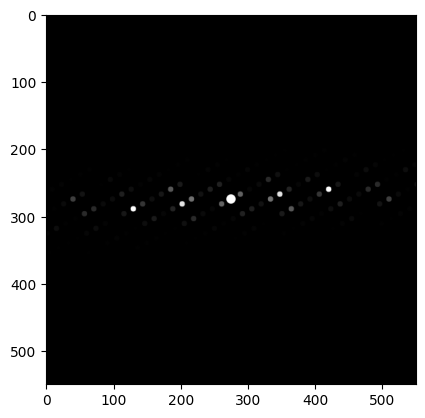

(1, 2048) [[0.25394464 0.74397403 0.7708416  ... 0.57497185 0.7224307  1.1760539 ]]


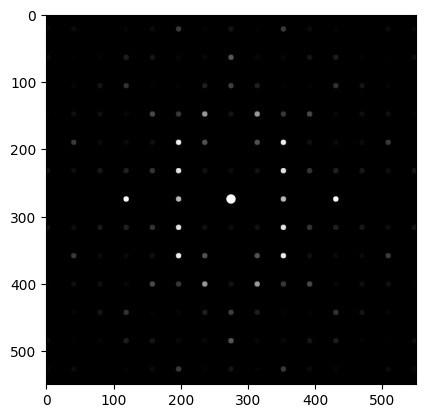

(1, 2048) [[0.2000363 1.0368295 0.7784757 ... 0.510992  1.6520706 0.5014655]]


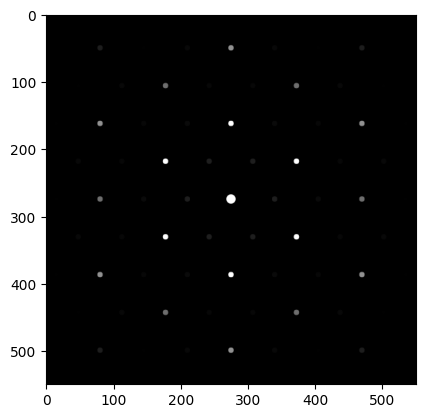

(1, 2048) [[0.22769311 0.9226891  0.21995038 ... 0.7683806  1.531578   0.7273564 ]]


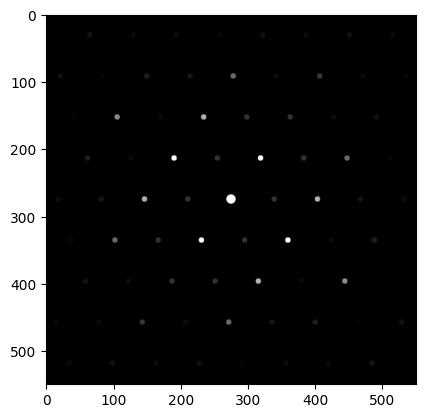

(1, 2048) [[0.87607545 0.9570727  1.2438496  ... 0.39130944 0.53728634 0.47121525]]


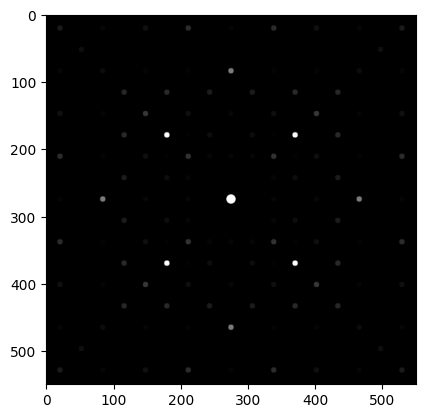

(1, 2048) [[0.17851585 0.9051413  0.62435615 ... 0.7802364  0.7513793  1.2041099 ]]


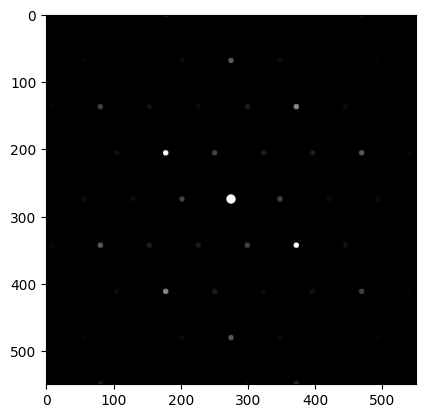

(1, 2048) [[0.14487329 0.8233379  0.58374965 ... 0.9208559  0.7253558  1.392614  ]]


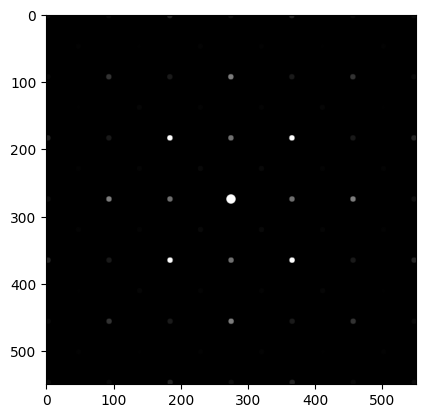

(1, 2048) [[0.20256843 1.0077425  0.75341815 ... 0.6660465  0.9141795  1.231652  ]]


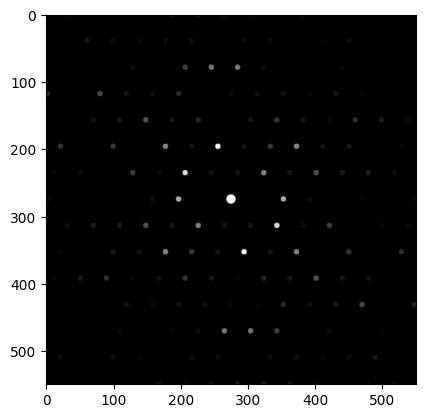

(1, 2048) [[0.16005765 0.82771415 0.684322   ... 0.99435616 0.51730794 1.1615554 ]]


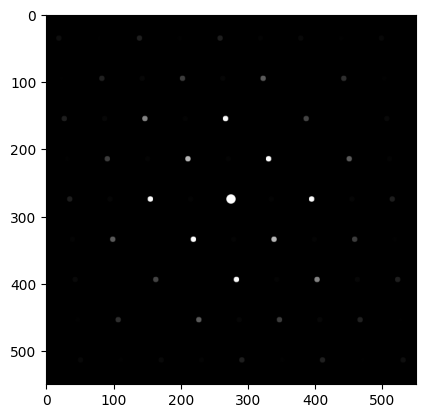

(1, 2048) [[0.35214522 0.88959795 0.802149   ... 0.9223845  0.731757   1.2827657 ]]


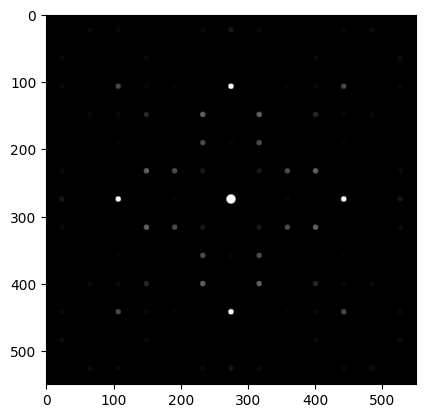

(1, 2048) [[0.3989474  0.62334025 0.78745455 ... 1.3464158  0.34767115 1.2209408 ]]


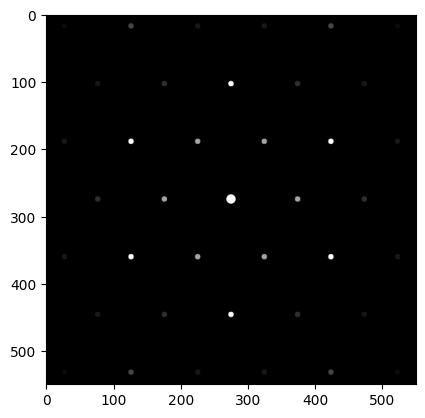

(1, 2048) [[0.289706   0.91387254 0.9593525  ... 0.80924743 0.38522688 1.2408621 ]]


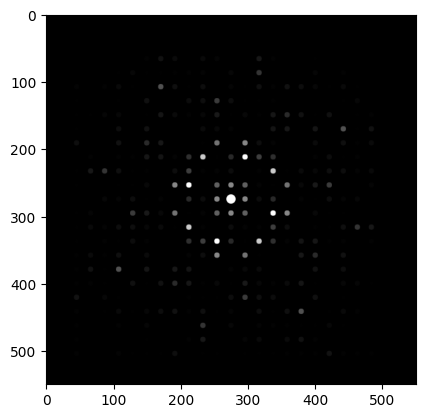

(1, 2048) [[0.13029851 0.8975636  0.579661   ... 0.46637225 0.706925   1.2568761 ]]


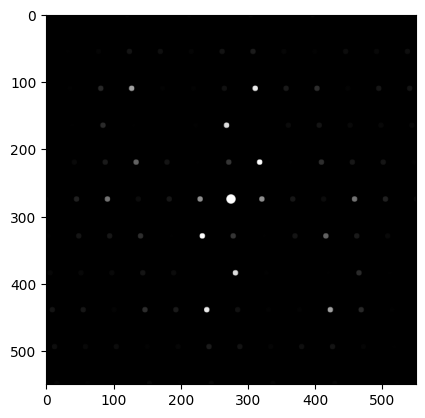

(1, 2048) [[0.07556551 0.9423797  0.44803435 ... 0.58524024 0.74272937 1.2984452 ]]


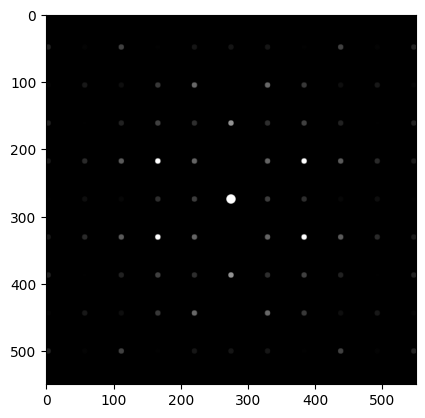

(1, 2048) [[0.22370496 0.9163567  0.9140385  ... 0.49041125 0.6185321  1.1918539 ]]


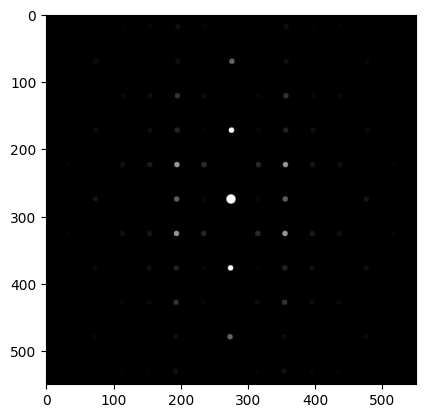

(1, 2048) [[0.4627727  1.0535318  0.66729736 ... 0.55982405 0.7434545  1.2803297 ]]


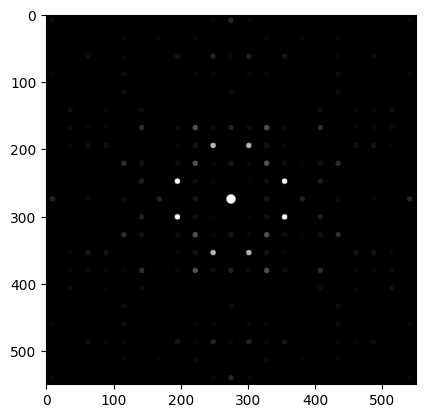

(1, 2048) [[0.7866701  1.0358341  0.61064607 ... 0.79919577 1.0233288  1.0063523 ]]


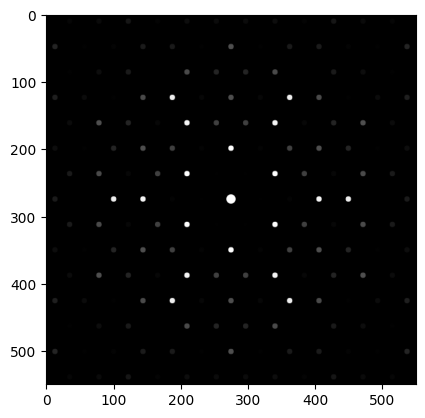

(1, 2048) [[0.5579787  0.69957423 1.0648688  ... 1.0168018  0.5792075  1.5325568 ]]


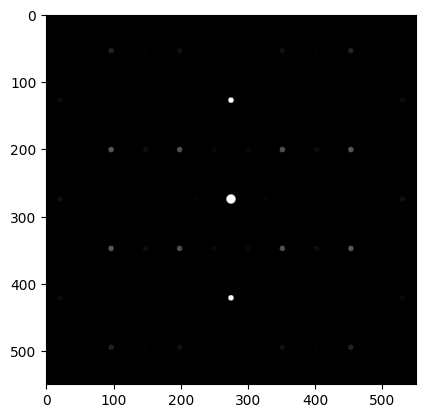

(1, 2048) [[0.32235363 0.7835229  0.65159464 ... 0.8291618  0.8655571  1.2965006 ]]


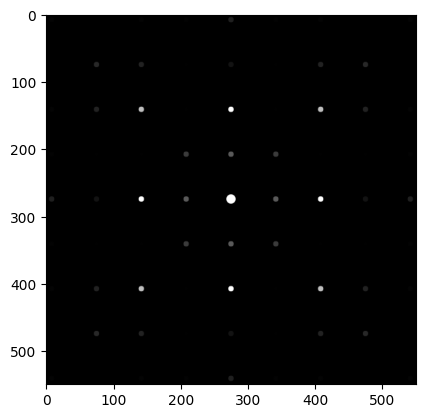

(1, 2048) [[0.62946576 0.91075397 0.66572136 ... 0.81597775 1.2205707  1.0048784 ]]


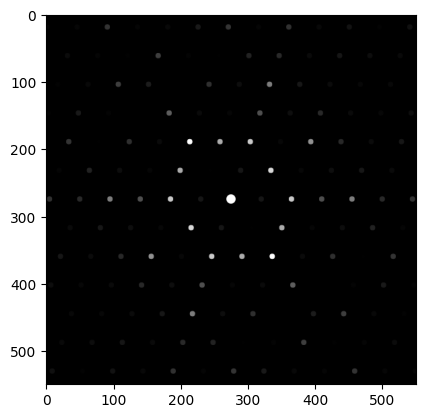

(1, 2048) [[0.57380366 0.9725481  0.23787113 ... 0.5287034  2.6200058  0.22346464]]


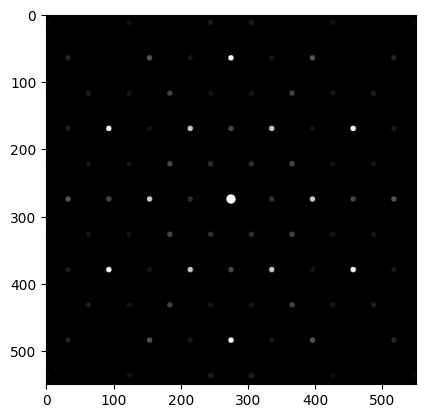

In [38]:
with h5py.File('/mnt/c/datasets/materials_project_root.h5', 'r') as h5:
    print(h5.keys())
    for k in list(h5.keys())[::100]:
        print(h5[k].shape, np.array(h5[k]))
        plt.imshow(plt.imread('/mnt/c/Users/yig319/Downloads/materials_project_root/materials_project_root/'+k))
        plt.show()